## ⚠️ Notice

## This material is the intellectual property of <font color="cyan">Dr. Lysa V. Comia.</font>  



Redistribution, reproduction, or use beyond personal reference is strictly prohibited without the prior written consent of the author.

## Connect Google Drive

In [1]:
# Reference: Dr. Lysa V. Comia, CustomYOLOv12_Doc_Lysa_[Student_Version].ipynb
from google.colab import drive

# Mount Google Drive to access datasets, pretrained models, and save training outputs.
# When prompted, follow the authorization link and paste the access code below.

drive.mount('/content/drive')


Mounted at /content/drive


## Installation

In [2]:
# Reference: Dr. Lysa V. Comia, CustomYOLOv12_Doc_Lysa_[Student_Version].ipynb
# Navigate to the project directory in Google Drive
# Ensure this path matches the location of your YOLOv12 project files.

%cd /content/drive/MyDrive/Proj_YOLOv12_FINAL

/content/drive/MyDrive/Proj_YOLOv12_FINAL


In [ ]:
# Reference: Dr. Lysa V. Comia, CustomYOLOv12_Doc_Lysa_[Student_Version].ipynb
# Clone the YOLOv12 repository
# (Uncomment this code below if cloning for the first time,
# then comment it out again after the initial setup to avoid recloning.)

#!git clone https://github.com/sunsmarterjie/yolov12.git

Cloning into 'yolov12'...
remote: Enumerating objects: 1169, done.
remote: Counting objects: 100% (586/586), done.
remote: Compressing objects: 100% (138/138), done.
remote: Total 1169 (delta 500), reused 448 (delta 448), pack-reused 583 (from 2)
Receiving objects: 100% (1169/1169), 1.92 MiB | 5.79 MiB/s, done.
Resolving deltas: 100% (521/521), done.
Updating files: 100% (333/333), done.


In [3]:
# Reference: Dr. Lysa V. Comia, CustomYOLOv12_Doc_Lysa_[Student_Version].ipynb
# Move into the YOLOv12 repository directory
# This assumes you have already cloned or copied the yolov12 folder inside your project path.

%cd yolov12

/content/drive/MyDrive/Proj_YOLOv12_FINAL/yolov12


In [ ]:
# Reference: Dr. Lysa V. Comia, CustomYOLOv12_Doc_Lysa_[Student_Version].ipynb
# Install project dependencies
# We overwrite requirements.txt with fixed versions to ensure compatibility in Colab.
# This prevents mismatched or outdated package versions during installation.

%%writefile requirements.txt
torch==2.2.2
torchvision==0.17.2
timm==1.0.14
albumentations==2.0.4
pycocotools==2.0.7
PyYAML==6.0.1
scipy==1.13.0
onnxslim==0.1.31
onnxruntime-gpu==1.18.0
gradio==4.44.1
opencv-python==4.9.0.80
psutil==5.9.8
py-cpuinfo==9.0.0
huggingface-hub==0.23.2
safetensors==0.4.3
numpy==1.26.4
supervision==0.22.0

Overwriting requirements.txt


In [ ]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.5/41.5 kB 4.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.6/289.6 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.0/725.0 kB 50.1 MB/s et

In [ ]:
# Upgrade core packaging tools to the latest versions
# Ensures smooth installation of dependencies and prevents build errors.
!pip install -U pip setuptools wheel

  Using cached setuptools-82.0.0-py3-none-any.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 35.1 MB/s eta 0:00:00
Using cached setuptools-82.0.0-py3-none-any.whl (1.0 MB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
pytensor 2.38.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
# Install ONNX with prebuilt binaries only (no source build)
# This avoids compilation errors in Colab by forcing a wheel install.
!pip install --only-binary=:all: "onnx==1.16.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 79.8 MB/s  0:00:00
  Attempting uninstall: onnx
    Found existing installation: onnx 1.20.1
    Uninstalling onnx-1.20.1:
      Successfully uninstalled onnx-1.20.1


In [ ]:
# Change directory to the YOLOv12 repository inside your project folder
# Make sure the yolov12 folder exists in this path before running.
%cd /content/drive/MyDrive/Proj_YOLOv12_FINAL/yolov12

/content/drive/MyDrive/Proj_YOLOv12_FINAL/yolov12


In [ ]:
# Install FlashAttention
!pip install flash-attn==2.6.3 --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 62.0 MB/s  0:00:00
  Preparing metadata (pyproject.toml) ... done
  Created wheel for flash-attn: filename=flash_attn-2.6.3-cp312-cp312-linux_x86_64.whl size=187236551 sha256=06dbb249e5a7cc37a6981f1d134b2318e3f4f29012fd21b0d2258b686683125d
  Stored in directory: /root/.cache/pip/wheels/03/03/b5/0373b7dd097f190e81c68b012f6a3d2514cf2225c2c1b0fd1d
Successfully built flash-attn


In [4]:
# Navigate back into the YOLOv12 project directory
# This ensures subsequent training or evaluation commands run inside the repo.
%cd /content/drive/MyDrive/Proj_YOLOv12_FINAL/yolov12

/content/drive/MyDrive/Proj_YOLOv12_FINAL/yolov12


In [ ]:
# Install YOLOv12 in editable/development mode
# This allows you to modify the repository code and immediately use the changes without reinstalling.
!pip install -e .

Obtaining file:///content/drive/MyDrive/Proj_YOLOv12_FINAL/yolov12
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ultralytics (pyproject.toml) ... done
  Created wheel for ultralytics: filename=ultralytics-8.3.63-0.editable-py3-none-any.whl size=20224 sha256=ff9423c58ae5e6b095b2ef56dd833fc8b1ac4df84636a717ea43e7027aab0b57
  Stored in directory: /tmp/pip-ephem-wheel-cache-c7_2441q/wheels/b4/b7/8c/8d6a19c3b7a0a6610a995a097b4f0e017b6b6ec6e57ebe8656
Successfully built ultralytics
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [ultralytics]


In [5]:
# Ensure we are inside the YOLOv12 repository directory
# This is important before running training, validation, or inference scripts.
%cd /content/drive/MyDrive/Proj_YOLOv12_FINAL/yolov12

/content/drive/MyDrive/Proj_YOLOv12_FINAL/yolov12


In [ ]:
# Install the specific Ultralytics version required for YOLOv12
# -U flag upgrades if an older version is already installed
!pip install -U ultralytics==8.3.176

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.6 MB/s eta 0:00:00


In [ ]:
# Reference: Dr. Lysa V. Comia, CustomYOLOv12_Doc_Lysa_[Student_Version].ipynb
# Download YOLOv12/YOLOv11 pretrained weights
# ⚠️ IMPORTANT: Uncomment ONLY the line you need, then comment it again after the first run
# to avoid downloading the file repeatedly in Colab.

# 📖 Full documentation and complete list of YOLOv12 model variants:
# https://docs.ultralytics.com/models/yolo12/

# --- For Object Detection ---
!wget https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo12n.pt

# # # --- For Object Segmentation ---
# !wget https://github.com/sunsmarterjie/yolov12/releases/download/seg/yolov12x-seg.pt


--2026-03-09 01:11:10--  https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo12n.pt
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/521807533/109788e3-f460-44d6-a21c-287771225cb8?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-09T01%3A54%3A50Z&rscd=attachment%3B+filename%3Dyolo12n.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-09T00%3A54%3A15Z&ske=2026-03-09T01%3A54%3A50Z&sks=b&skv=2018-11-09&sig=wG%2F16alHnR1QyPKC0jr6jxnNanfjsb1LkAXjpC39Ito%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MzAxODk3MCwibmJmIjoxNzczMDE4NjcwLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmU

# DATASET

In [6]:
import yaml  #PyYAML documentation: https://pyyaml.org/wiki/PyYAMLDocumentation. This is for reading the data.yaml file that has all my dataset info. Been using this since my earlier ML projects.
import os  # Python os.path documentation: https://docs.python.org/3/library/os.path.html. This lets me check if folders actually exist and handle file paths. Pretty basic stuff we use all the time.

# This is where I saved my data.yaml file in Google Drive
yaml_path = "/content/drive/MyDrive/cable-damage-aug/data.yaml"

# Gotta check if the file is actually there first - learned this after getting way too many file not found errors lol
if os.path.exists(yaml_path):

    # Opening the yaml file to read it. The 'with' thing automatically closes it so no need to worry about that.
    with open(yaml_path, 'r') as f:

        # This loads everything from the yaml into a dictionary so I can easily grab what I need
        data = yaml.safe_load(f)

    # Just printing everything to double check it loaded right. Helps catch any typos in the file.
    print("data.yaml contents:")
    print(data)

    # Getting the path to my training images from the yaml file.Reference, https://docs.ultralytics.com/datasets/detect/
    train_path = data['train']
    print("\nTrain path:", train_path)

    # The path in yaml has ../ in it so I need to build the full path. Took me a while to figure this out honestly.
    full_train = os.path.join(os.path.dirname(yaml_path), train_path.replace('../', ''))
    print("Full train path:", full_train)

    # Making sure the training folder actually exists. Would suck to start training and realize it's missing.
    if os.path.exists(full_train):
        print("Train folder exists")

        # Counting how many images I have for training
        images = os.listdir(full_train)
        print("Images in train:", len(images))
    else:
        print("Train folder missing")

    # Same thing but for validation data. Need this to check how the model performs.
    val_path = data['val']
    print("\nVal path:", val_path)

    # Building the full validation path the same way as train
    full_val = os.path.join(os.path.dirname(yaml_path), val_path.replace('../', ''))
    print("Full val path:", full_val)

    # Checking if validation folder exists. Can't validate without validation data obviously.
    if os.path.exists(full_val):
        print("Validation folder exists")

        # Counting validation images to make sure I have enough for proper testing
        images = os.listdir(full_val)
        print("Images in validation:", len(images))
    else:
        print("Validation folder missing")

    # Same thing but for test data
    test_path = data['test']
    print("\nTest path:", test_path)

    # Building the full test path the same way as train and val
    full_test = os.path.join(os.path.dirname(yaml_path), test_path.replace('../', ''))
    print("Full test path:", full_test)

    # Checking if test folder exists
    if os.path.exists(full_test):
        print("Test folder exists")

        # Counting test images
        images = os.listdir(full_test)
        print("Images in test:", len(images))
    else:
        print("Test folder missing")

    # Number of classes I'm detecting - in this case it's 2 (fertile and infertile eggs)
    print("\nNumber of classes:", data['nc'])

    # The actual class names. Good to double check these are right.
    print("Class names:", data['names'])

    # Quick summary so I can see everything's set up properly at a glance
    print("Classes:", data['nc'], "-", data['names'][0], "and", data['names'][1])

else:
    # Error message if file isn't found. Happens sometimes when I mess up the path.
    print("data.yaml not found at", yaml_path)

data.yaml contents:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 3, 'names': ['break', 'heat_damage', 'wear'], 'roboflow': {'workspace': 'nodkeyobma', 'project': 'cable-damage-algo', 'version': 2, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/nodkeyobma/cable-damage-algo/dataset/2'}}

Train path: ../train/images
Full train path: /content/drive/MyDrive/cable-damage-aug/train/images
Train folder exists
Images in train: 2800

Val path: ../valid/images
Full val path: /content/drive/MyDrive/cable-damage-aug/valid/images
Validation folder exists
Images in validation: 400

Test path: ../test/images
Full test path: /content/drive/MyDrive/cable-damage-aug/test/images
Test folder exists
Images in test: 200

Number of classes: 3
Class names: ['break', 'heat_damage', 'wear']
Classes: 3 - break and heat_damage


In [7]:
# This prints a header to show what this script does
print("DATASET INFO")
# SET UP MY FOLDER section
import os  # 'os' is a Python library that lets you interact with your operating system
           # It's like having a remote control for your files and folders

# Create folder for my files in Google Drive
# This is where we'll save our output files
folder = '/content/drive/MyDrive/Proj_YOLOv12_FINAL'  # Path string pointing to Google Drive folder

# os.makedirs() creates a new folder (and any parent folders if they don't exist)
# exist_ok=True means "don't give an error if the folder already exists"
os.makedirs(folder, exist_ok=True)  # Like 'mkdir -p' in Linux

# The 'f' before the string makes it an f-string - you can put variables inside {}
print(f"Created folder: {folder}")  # Shows the path where files will be saved


# COUNT IMAGES IN MY DATASET section

# Path to my dataset - where all my training images are stored
dataset = "/content/drive/MyDrive/cable-damage-aug"

# List of image file extensions I want to count
# The dot before each extension is important - it's part of the filename
image_types = ['.jpg', '.jpeg', '.png']  # Common image formats

print(f"\nLooking for images in: {dataset}")  # \n adds a blank line before this

# Check if dataset folder exists
# os.path.exists() returns True if the path exists, False if it doesn't
if not os.path.exists(dataset):  # if dataset folder is NOT found
    print(f"Warning: Can't find dataset at {dataset}")  # Show warning message
    print("   Using estimated values")
    total_images = 1000  # Fallback value - just an estimate if real data not found
else:  # If the folder DOES exist
    # Count actual images
    total_images = 0  # Start counter at zero

    # os.walk() goes through ALL folders and subfolders
    # It returns three things:
    # root = current folder path
    # dirs = list of subfolders in current folder
    # files = list of files in current folder
    for root, dirs, files in os.walk(dataset):
        # Loop through each file in the current folder
        for file in files:
            # Check if file is an image
            # any() returns True if at least one condition is True
            # file.lower() converts filename to lowercase (so .JPG matches .jpg)
            # .endswith(ext) checks if filename ends with any extension in our list
            if any(file.lower().endswith(ext) for ext in image_types):
                total_images += 1  # Add 1 to our counter (increment by 1)

    print(f"   Found {total_images} images")  # Show how many images we found


# MY DATASET INFO section - defining dataset properties

img_h = 640           # image height in pixels (all images are 640 pixels tall)
img_w = 640           # image width in pixels (all images are 640 pixels wide)
num_c = 3             # number of damage classes: 0=break, 1=heat_damage, 2=wear
dataset_url = "https://universe.roboflow.com/nodkeyobma/cable-damage-algo/dataset/1 \nhttps://drive.google.com/drive/folders/15pBjofMhlOJqZK3_v8y1BrPGalRucnp0?usp=sharing"  # Source URL

print(f"\nMy dataset info:")  # Print section header
print(f"   Total images      = {total_images}")  # Show the count we found
print(f"   Image height      = {img_h}")  # Show height
print(f"   Image width       = {img_w}")  # Show width
print(f"   Number of classes = {num_c}")  # Show number of classes
print(f"   Class names       = break, heat_damage, wear")  # List the actual class names
print(f"   Dataset URL       = {dataset_url}")  # Show where dataset came from

# SAVE TO A FILE section - creating a text file

# Create text file path (simple .txt file)
# We combine the folder path with the filename using f-string
info = f'{folder}/dataset_info.txt'  # This will be something like: /path/to/folder/dataset_info.txt

# Open the file for writing ('w' means write mode - will create/overwrite the file)
# 'with' ensures the file is properly closed after we're done (even if errors occur)
with open(info, 'w') as f:  # 'f' is our file object variable
    # Write content to the file using f.write()
    f.write("STEEL CABLE DAMAGE DETECTION DATASET\n")
    f.write("=====================================\n\n")

    f.write(f"Total images: {total_images}\n")
    f.write(f"Image dimensions: {img_w} x {img_h} pixels\n")
    f.write(f"Number of classes: {num_c}\n")
    f.write(f"Class names: break, heat_damage, wear\n\n")

    f.write(f"Dataset source:\n{dataset_url}\n")
    f.write(f"\nFile created on: 2026-03-06")

# Tell user where we saved the file
print(f"\nSaved to {info}")

DATASET INFO
Created folder: /content/drive/MyDrive/Proj_YOLOv12_FINAL

Looking for images in: /content/drive/MyDrive/cable-damage-aug
   Found 3400 images

My dataset info:
   Total images      = 3400
   Image height      = 640
   Image width       = 640
   Number of classes = 3
   Class names       = break, heat_damage, wear
   Dataset URL       = https://universe.roboflow.com/nodkeyobma/cable-damage-algo/dataset/1 
https://drive.google.com/drive/folders/15pBjofMhlOJqZK3_v8y1BrPGalRucnp0?usp=sharing

Saved to /content/drive/MyDrive/Proj_YOLOv12_FINAL/dataset_info.txt


## Training
# Reference: Dr. Lysa V. Comia, CustomYOLOv12_Doc_Lysa_[Student_Version].ipynb

In [ ]:
from ultralytics import YOLO

# Initialize the YOLO model
# ⚠️ Use the appropriate checkpoint:
# - yolo12n.pt       → for object detection
# - yolo11n-seg.pt   → for object segmentation
model = YOLO('/content/drive/MyDrive/Proj_YOLOv12_FINAL/yolov12/yolo12n.pt')

# Train the model
results = model.train(
    data='/content/drive/MyDrive/cable-damage-aug/data.yaml',  # dataset config file
    epochs=120,       # maximum epochs (early stopping may end sooner)
    patience=15,       # stop if no improvement for 15 epochs
    batch=8,           # batch size
    imgsz=640,         # input image size
    scale=0.5,         # data augmentation scaling
    mosaic=1.0,        # mosaic augmentation probability
    mixup=0.0,         # mixup probability
    copy_paste=0.1,    # copy-paste augmentation probability
    close_mosaic=10,   # disable mosaic augmentation in the last 10 epochs
    device="0",        # set to "0" for GPU, "cpu" for CPU
    save=True          # save both best.pt and last.pt
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/yolov12/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
FlashAttention is not available on this device. Using scaled_dot_product_attention instead.
New https://pypi.org/project/ultralytics/8.4.21 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.2.2+cu121 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/Proj_YOLOv12_FINAL/yolov12/yolo12n.pt, data=/content/drive/MyDrive/cable-damage-aug/data.yaml, epochs=120, time=None, patience=15, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, r

100%|██████████| 755k/755k [00:00<00:00, 25.3MB/s]


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  2    174720  ultralytics.nn.modules.block.A2C2f           [128, 128, 2, True, 4]        
  7                  -1  1    295424  ultralytics

100%|██████████| 5.26M/5.26M [00:00<00:00, 80.2MB/s]


AMP: checks passed ✅


...

    120/120      1.97G      1.484     0.7554      1.337         23        640: 100%|██████████| 350/350 [01:59<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 25/25 [00:06<00:00,  3.78it/s]

                   all        400        791      0.849      0.763      0.834       0.38



120 epochs completed in 4.439 hours.
Optimizer stripped from /content/drive/MyDrive/Proj_YOLOv12_FINAL/yolov12/runs/detect/train/weights/last.pt, 5.5MB
Optimizer stripped from /content/drive/MyDrive/Proj_YOLOv12_FINAL/yolov12/runs/detect/train/weights/best.pt, 5.5MB

Validating /content/drive/MyDrive/Proj_YOLOv12_FINAL/yolov12/runs/detect/train/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.2.2+cu121 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 376 layers, 2,538,881 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 25/25 [00:07<00:00,  3.30it/s]


                   all        400        791      0.846      0.759      0.835      0.381
                 break        192        237      0.802      0.764      0.842      0.366
           heat_damage        188        249      0.899      0.929      0.922      0.447
                  wear         46        305      0.836      0.585      0.741       0.33
Speed: 0.3ms preprocess, 5.9ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/drive/MyDrive/Proj_YOLOv12_FINAL/yolov12/runs/detect/train


# Model .eval()

In [ ]:
# Import the YOLO class from Ultralytics library
from ultralytics import YOLO
import pandas as pd

# Path to my dataset configuration file
data_yaml = "/content/drive/MyDrive/cable-damage-aug/data.yaml"

# Evaluate only the model in the "train" folder
print("Testing Model")

# Load my trained model from the weights file
model = YOLO("/content/drive/MyDrive/Proj_YOLOv12_FINAL/yolov12/runs/detect/train/weights/best.pt")

# Evaluate the model on the test dataset
metrics = model.val(data=data_yaml)

# Get results
mAP50 = round(metrics.box.map50, 4)
precision = round(metrics.box.mp, 4)
recall = round(metrics.box.mr, 4)

# Calculate F1 score
if precision + recall > 0:
    f1 = round(2 * (precision * recall) / (precision + recall), 4)
else:
    f1 = 0

# Create a single-row DataFrame with the results
performance_table = pd.DataFrame(
    [["Model A", mAP50, precision, recall, f1]],
    columns=["Model", "mAP50", "Precision", "Recall", "F1"]
)

# Display the results
print("\nModel Performance Results:")
performance_table

Testing Model
Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.2.2+cu121 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 376 layers, 2,538,881 parameters, 0 gradients, 6.3 GFLOPs


val: Scanning /content/drive/MyDrive/cable-damage-aug/valid/labels.cache... 400 images, 0 backgrounds, 0 corrupt: 100%|██████████| 400/400 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 25/25 [00:10<00:00,  2.42it/s]


                   all        400        791      0.847      0.759      0.835      0.381
                 break        192        237      0.801      0.764      0.843      0.367
           heat_damage        188        249      0.901      0.928      0.922      0.446
                  wear         46        305       0.84      0.585      0.741      0.331
Speed: 0.2ms preprocess, 8.6ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/drive/MyDrive/Proj_YOLOv12_FINAL/yolov12/runs/detect/val

Model Performance Results:


,Model,mAP50,Precision,Recall,F1
0,Model A,0.8353,0.8473,0.7588,0.8006


## Testing


image 1/1 /content/drive/MyDrive/cable-damage-aug/test/images/IMG_6277_MOV-14_jpg.rf.de7ec0016f8705510e905fa2938f2015.jpg: 384x640 1 break, 1 heat_damage, 21.7ms
Speed: 2.8ms preprocess, 21.7ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


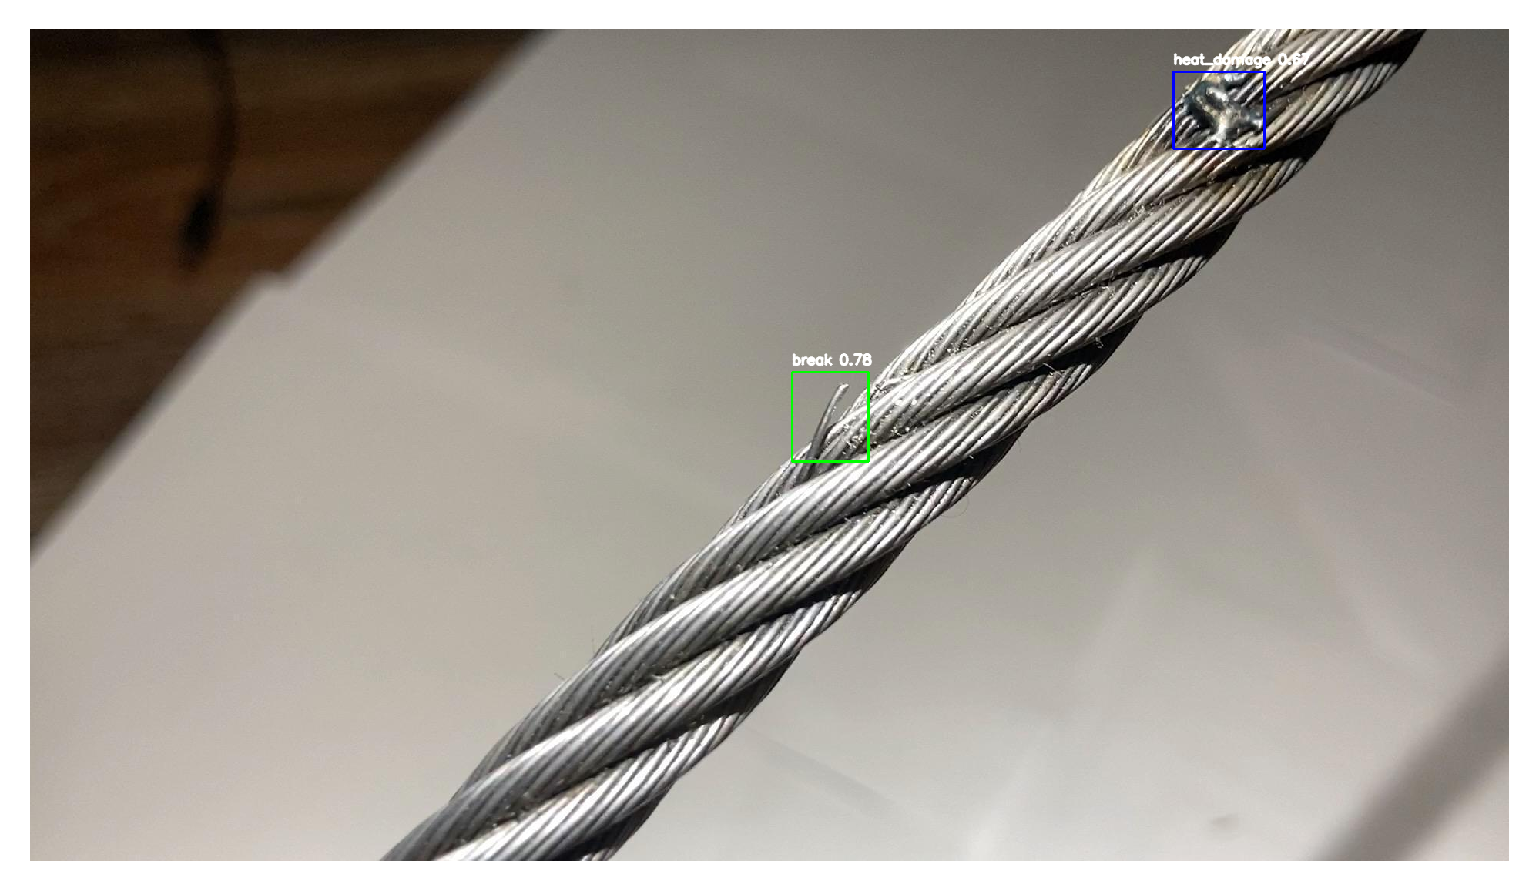

In [ ]:
# Reference: Dr. Lysa V. Comia, CustomYOLOv12_Doc_Lysa_[Student_Version].ipynb
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt
import numpy as np

# Load trained YOLOv12 segmentation model weights
model = YOLO("/content/drive/MyDrive/Proj_YOLOv12_FINAL/yolov12/runs/detect/train/weights/best.pt")

# Test image path
img_path = "/content/drive/MyDrive/cable-damage-aug/test/images/IMG_6277_MOV-14_jpg.rf.de7ec0016f8705510e905fa2938f2015.jpg"

# Run inference
results = model(img_path)

# Process and visualize results
for r in results:
    # Load the original image (full resolution)
    img = cv2.imread(img_path)

    # Overlay segmentation masks, this adds colored overlays on top of detected objects
if r.masks is not None:  # Check if there are any segmentation masks in the results
    masks = r.masks.data.cpu().numpy()  # Convert the mask data from GPU to CPU and then to numpy array
    for mask in masks:  # Loop through each individual mask
        mask = mask.astype(np.uint8) * 255  # Convert mask values (0-1) to 0-255 range for image display
        colored_mask = np.zeros_like(img)  # Create a blank colored image with same dimensions as original
        colored_mask[:, :, 2] = mask  # Put the mask in the red channel (index 2) to create red overlay
        img = cv2.addWeighted(img, 1.0, colored_mask, 0.5, 0)  # Blend original image and red overlay (50% transparency)

# Draw bounding boxes, labels, and confidence scores
boxes = r.boxes.xyxy.cpu().numpy()  # Get bounding box coordinates (x1,y1,x2,y2) and convert to numpy array
scores = r.boxes.conf.cpu().numpy()  # Get confidence scores for each detection (how sure the model is)
class_ids = r.boxes.cls.cpu().numpy().astype(int)  # Get class IDs and convert them to integers
names = model.names  # Get the dictionary mapping class IDs to class names (e.g., {0: "break", 1: "heat_damage"})

# Define colors for different classes (BGR format for OpenCV)
# Class 0: Green (0, 255, 0)- break
# Class 1: Blue (255, 0, 0)- heat_damage
# Class 2: Red (0, 0, 255)- wear
# Add more colors if you have more classes
class_colors = [  # Create a list where index matches class ID
    (0, 255, 0),    # Green for class 0 (BGR format: Blue=0, Green=255, Red=0)
    (255, 0, 0),    # Blue for class 1 (BGR format: Blue=255, Green=0, Red=0)
    (0, 0, 255)     # Red for class 2 (BGR format: Blue=0, Green=0, Red=255)
]

for box, score, cls_id in zip(boxes, scores, class_ids):  # Loop through each detection (box, score, class together)
    x1, y1, x2, y2 = map(int, box)  # Convert box coordinates from float to integers for drawing
    label = f"{names[cls_id]} {score:.2f}"  # Create label text combining class name and confidence score

    # Get color for this class (default to white if class ID > available colors)
    color = class_colors[cls_id] if cls_id < len(class_colors) else (255, 255, 255)  # Pick color based on class ID

    # Draw rectangle with class-specific color
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)  # Draw rectangle from top-left to bottom-right with class color, thickness=2

    # Put label + score above the box
    cv2.putText(img, label, (x1, max(y1 - 10, 0)),  # Position text above box (x1, y1-10) but not above image top
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2,  # Use simple font, size 0.6, white color, thickness 2
                lineType=cv2.LINE_AA)  # Use anti-aliased line for smoother text

# Display image at original resolution
h, w = img.shape[:2]  # Get image height and width from image shape
dpi = 300  # Set display resolution to 300 dots per inch
fig_w, fig_h = w / dpi, h / dpi  # Calculate figure size in inches based on image pixels and DPI
fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)  # Create matplotlib figure with exact size to maintain resolution

ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), interpolation='nearest')  # Convert BGR to RGB and display image
ax.axis("off")  # Turn off axes to show only the image
plt.show()  # Display the final image with all detections

# ⚠️ Notice

## This material is the intellectual property of <font color="cyan">Dr. Lysa V. Comia.</font>  


## 📌 Notice on Use, Redistribution, and Ethical Compliance  

Redistribution, reproduction, or use of this material beyond personal reference is **strictly prohibited** without the prior written consent of the author. Unauthorized copying, modification, or dissemination—whether for commercial, academic, or institutional purposes—violates intellectual property rights and may result in legal or disciplinary action.  

---

### 🔒 AI Governance and Ethics Considerations  
This work must **not** be used in ways that:  
- ❌ **Compromise data privacy** or violate data protection regulations (e.g., GDPR, Philippine Data Privacy Act).  
- ❌ **Perpetuate bias or discrimination** by misusing algorithms, datasets, or results.  
- ❌ **Enable harmful applications**, including surveillance, profiling, or uses that undermine human rights.  
- ❌ **Misrepresent authorship or credit**, such as plagiarism or omission of proper citations.  

---

### ✅ Responsible Use Principles  
Users are expected to follow responsible research and innovation practices, ensuring that any derivative work is:  
- **Transparent** → Clear acknowledgment of sources and methodology.  
- **Accountable** → Proper attribution and disclosure of limitations.  
- **Beneficial to society** → Applications that align with ethical standards and do not cause harm.  

---

📢 For **any intended use** (academic, research, or practical), prior written approval must be obtained from the author to ensure compliance with both **legal requirements** and **ethical AI practices**.  


# COMPLEXITY EXTRACTION

In [ ]:
# This first line prints a title/header to show what the program does
# The \n creates a blank line before the text for better formatting
print("SYMBOL DEFINITIONS FOR COMPLEXITY ANALYSIS")

# This is a comment explaining that this script defines all symbols used in the analysis
# The 'import os' line imports the operating system module (though it's not actually used in this code)
import os

# DATASET SYMBOLS section - these variables store information about our image dataset
n = 3400           # 'n' = total number of training images (like having 1000 photos to learn from)
h = 640            # 'h' = image height in pixels (each image is 640 pixels tall)
w = 640            # 'w' = image width in pixels (each image is 640 pixels wide)
c = 3              # 'c' = number of damage classes we're detecting (break, heat_damage, wear)

# TRAINING SYMBOLS section - these variables store info about how we train the model
b = 8              # 'b' = batch size (we process 8 images at a time, like studying in groups)
L = 497            # 'L' = number of neural network layers (the model has 497 layers deep!)

# YOLO-SPECIFIC SYMBOLS section - YOLO is an object detection algorithm
downsample = 32    # How much we shrink the image (640/32 = 20, so image becomes 20x20 grid)
gh = h // downsample  # 'gh' = grid height = 20 cells (floor division // gives whole number)
gw = w // downsample  # 'gw' = grid width = 20 cells
a = 3                 # 'a' = anchors per grid cell (3 different box shapes at each cell)
p = gh * gw * a       # 'p' = total proposals = 20 × 20 × 3 = 1200 (boxes to check for objects)

# CNN ARCHITECTURE SYMBOLS section - CNN = Convolutional Neural Network
cin = 256          # 'cin' = average input channels per layer (like 256 features coming in)
cout = 256         # 'cout' = average output channels per layer (256 features going out)
k = 3              # 'k' = kernel size (3x3 filter, like a 3x3 magnifying glass)
k2 = k * k         # 'k²' = kernel area = 9 (3×3 = 9 pixels in the filter)
total_params = 2550201

# PRINT SECTION - this is where we actually display all the values we defined

# The :5 in {n:5} means "reserve 5 spaces for this number" (right-aligned formatting)
print(f"   n  = {n:5}  (total training images)")
print(f"   h  = {h:5}  (image height in pixels)")
print(f"   w  = {w:5}  (image width in pixels)")
print(f"   c  = {c:5}  (number of damage classes: break, heat_damage, wear)")
print(f"   b  = {b:5}  (batch size)")
print(f"   L  = {L:5}  (number of layers)")
print(f"   gh = {gh:5}  (grid height = h/{downsample})")
print(f"   gw = {gw:5}  (grid width = w/{downsample})")
print(f"   a  = {a:5}  (anchors per grid cell)")
# The f-string shows the calculation: {gh} × {gw} × {a}
print(f"   p  = {p:5}  (total proposals = gh × gw × a = {gh} × {gw} × {a})")
print(f"   cin  = {cin:5}  (average input channels)")
print(f"   cout = {cout:5}  (average output channels)")
print(f"   k    = {k:5}  (kernel size)")
print(f"   k²   = {k2:5}  (kernel area = k²)")

SYMBOL DEFINITIONS FOR COMPLEXITY ANALYSIS
   n  =  3400  (total training images)
   h  =   640  (image height in pixels)
   w  =   640  (image width in pixels)
   c  =     3  (number of damage classes: break, heat_damage, wear)
   b  =     8  (batch size)
   L  =   497  (number of layers)
   gh =    20  (grid height = h/32)
   gw =    20  (grid width = w/32)
   a  =     3  (anchors per grid cell)
   p  =  1200  (total proposals = gh × gw × a = 20 × 20 × 3)
   cin  =   256  (average input channels)
   cout =   256  (average output channels)
   k    =     3  (kernel size)
   k²   =     9  (kernel area = k²)


In [ ]:
import sys
# sys is a Python module that lets me mess with system stuff
# I need this to tell Python where to find my files

sys.path.append('/content/drive/MyDrive/Proj_YOLOv12_FINAL')
# This is the folder where I saved all my project files
# Python normally only looks in certain folders for modules
# I'm adding my Google Drive folder to that list so Python can find my files
# Without this line, I'd get "ModuleNotFoundError" when I try to import

from my_pipeline import MyCablePipeline
# This imports my main pipeline class from my_pipeline.py
# MyCablePipeline is the class that has all the functions:
#   - preprocess()
#   - forward()
#   - compute_loss()
#   - backward()
#   - postprocess()
#   - run_demo()

from pipeline_tags import COMPONENT_INFO, get_component_functions
# This imports stuff from my configuration file (pipeline_tags.py)
# COMPONENT_INFO is a dictionary that stores:
#   - what type each component is (preprocess, forward, etc.)
#   - what symbols each component uses (b, h, w, L, p, c)
#   - a description of what each component does
#
# get_component_functions() is a helper function that returns:
#   ['preprocess', 'forward', 'compute_loss', 'backward', 'postprocess']
# It just lists all the component function names

from tag_complexity_extractor import analyze_pipeline
# This imports my complexity analyzer from tag_extractor.py
# analyze_pipeline() is a function that:
#   - reads my_pipeline.py file
#   - looks at all the loops and conditionals
#   - figures out the Big-O, Big-Omega, and Big-Theta complexity
#   - returns a dictionary with all the results

print(" pipeline and extractor loaded")
# Just a confirmation message so I know everything imported correctly

print(f"tagged components: {get_component_functions()}")
# This prints out the list of component functions
# get_component_functions() returns something like:
#   ['preprocess', 'forward', 'compute_loss', 'backward', 'postprocess']
# The f-string lets me put that list right inside the printed message

 pipeline and extractor loaded
tagged components: ['preprocess', 'forward', 'compute_loss', 'backward', 'postprocess']


In [ ]:
# Import the MyCablePipeline class from the my_pipeline module
# This allows us to create an instance of the pipeline we defined earlier
from my_pipeline import MyCablePipeline

# Create a pipeline instance with 10 total images, 32x32 pixel images, and 3 damage classes
# The small image size (32x32) makes the pipeline run quickly for testing purposes
test_pipe = MyCablePipeline(5, 32, 32 , 3)  # Small images

# Override the number of layers to just 5 instead of the default 497
# This line is disabled but would dramatically reduce computation time if uncommented
test_pipe.L = 5  # Override to just 5 layers

# Override the input channels per layer from 256 to 16 for faster computation
# Reducing channels decreases the total number of operations in convolutional layers
test_pipe.cin = 16  # Smaller channels

# Override the output channels per layer from 256 to 16 for consistency
# This matches the reduced input channels and further speeds up the pipeline
test_pipe.cout = 16

# Execute the complete pipeline demonstration with all five components
# This runs preprocessing, forward pass, loss computation, backpropagation, and post-processing
test_pipe.run_demo()

✅ Pipeline ready for 3-class steel cable damage detection
   n=5, h=32, w=32, b=8, L=497
   Grid: 1×1, Anchors: 3
   Total predictions (p) = 3
   Model parameters: 2,550,201

PIPELINE DEMO

STEP 1: Preprocess
    Preprocessed tensor shape: torch.Size([8, 3, 32, 32])

STEP 2: Forward
    Activations stored: 5 layers
    Predictions shape: torch.Size([8, 1, 1, 3, 8])

STEP 3: Loss
  Computing loss for steel cable damage detection...
    Processing 8×1×1×3 = 24 grid cells
    Combined targets shape: torch.Size([8, 1, 1, 3, 8])
    Total loss terms: 192

⬅STEP 4: Backward
    Activation gradients: 5 layers
    Weight gradients shape: torch.Size([293142528])

STEP 5: Postprocess
  Applying NMS with numpy arrays for space tracking...
    Image 0: 1 high conf → 1 after NMS
    Image 1: 2 high conf → 2 after NMS
    Image 2: 2 high conf → 2 after NMS
    Image 3: 3 high conf → 3 after NMS
    Image 4: 1 high conf → 1 after NMS
    Image 5: 2 high conf → 2 after NMS
    Image 6: 1 high conf → 1

In [ ]:
###Final
# EXTRACT COMPLEXITY USING TAG FILE
print("EXTRACTING COMPLEXITY.......")
# This prints a message to the console to show the program has started
# The multiple dots create a dramatic effect like something is loading

pipeline_file = '/content/drive/MyDrive/Proj_YOLOv12_FINAL/my_pipeline.py'
# This creates a variable called 'pipeline_file' and stores a file path in it
# The path points to a Python file in Google Drive (since it starts with /content/drive)
# This is likely a YOLOv12 project file that contains the pipeline code we want to analyze

print(f"\n Analyzing {pipeline_file}.....")
# This prints a message showing which file is being analyzed
# The 'f' before the string means it's an f-string - it lets us insert variables directly
# The '\n' adds a new line before the message for better formatting
# {pipeline_file} gets replaced with the actual file path we stored above

# Run enhanced analysis
# Another comment explaining what happens next

results = analyze_pipeline(pipeline_file, COMPONENT_INFO)
# This is the key line - it calls a function named 'analyze_pipeline'
# The function takes two arguments:
#   1. pipeline_file - the file we want to analyze
#   2. COMPONENT_INFO - likely a dictionary or list containing information about
#      different components in the pipeline (like what to look for)
# The function returns results which are stored in a variable called 'results'

print("\nEXTRACTION RESULTS:")
# Prints a header for the results section
# '\n' adds a blank line before this text

print("-"*40)
# This prints a line of 40 dashes as a visual separator
# It makes the output look organized and professional

for component, bounds in results.items():
    # This is a for loop that iterates through the 'results' dictionary
    # .items() gives us both the key (component name) and value (bounds data)
    # Each iteration gives us one component and its complexity bounds

    print(f"\n{component.upper()}:")
    # Prints the component name in ALL CAPS (upper() converts to uppercase)
    # The '\n' adds a blank line before each component for spacing

    print(f"  Time: O={bounds['time']['O']:15} Ω={bounds['time']['Ω']:15} Θ={bounds['time']['Θ']}")
    # This prints the TIME complexity analysis for the current component
    # It shows three bounds:
    #   O (Big O) - Worst case complexity
    #   Ω (Big Omega) - Best case complexity
    #   Θ (Big Theta) - Average case complexity
    # The ':15' adds spacing to align the output neatly (reserves 15 characters)

    print(f"  Space: O={bounds['space']['O']:15} Ω={bounds['space']['Ω']:15} Θ={bounds['space']['Θ']}")
    # This prints the SPACE complexity analysis (memory usage)
    # Same format as time complexity but for memory/storage
    # Also shows worst, best, and average cases with aligned formatting

EXTRACTING COMPLEXITY.......

 Analyzing /content/drive/MyDrive/Proj_YOLOv12_FINAL/my_pipeline.py.....

   Analyzing: preprocess (from preprocess)
       Tensor allocation: b * 3 * h * w (depth: 0)
       Added loop: b (depth: 1)
       Added loop: h (depth: 2)
       Added loop: w (depth: 3)
    Total loops found: 3
    Total allocations: 1
    Calculating time bounds from:
      All loops: ['b', 'h', 'w']
      Block boundaries: [0, 0, 0, 0, 0, 0, 3, 3]
      Conditionals: 0

   Analyzing: forward (from forward)
       Added loop: L (depth: 1)
       Tensor allocation: b * cout * h * w (depth: 1)
       Added loop: b (depth: 2)
       Added loop: cout (depth: 3)
       Added loop: cin (depth: 4)
       Added loop: h (depth: 5)
       Added loop: w (depth: 6)
       Added loop: k2 (depth: 7)
       Added loop: b (depth: 2)
       Added loop: cin (depth: 5)
       Added loop: cout (depth: 6)
       Tensor allocation: b * gh * gw * a * (c + 5) (depth: 0)
    Total loops found: 10
    To

# REPORT GENERATION

In [ ]:
# COMPLEXITY REPORT GENERATOR
# This script takes all the complexity analysis we did and creates a nice formatted report

# Create an empty list to hold each line of my report
# I'll add lines one by one, then join them all at the end
report_lines = []  # Like a shopping list, but for report lines
# Lists in Python are like containers that can hold multiple items in order

# Add a big title at the top
report_lines.append("=" * 60)
# .append() adds something to the end of the list
# "=" * 60 creates a string of 60 equals signs - like a decorative line

report_lines.append("STEEL CABLE DAMAGE DETECTION - COMPLEXITY ANALYSIS REPORT")
report_lines.append("=" * 60)
report_lines.append("")  # Empty line for spacing - like pressing Enter twice

# Let's add today's date so my professor knows when I did this analysis
import datetime  # Python's built-in module for dates and times
# datetime is like a calendar and clock built into Python

current_time = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
# datetime.datetime.now() gets the current moment
# .strftime() is "string format time" - it converts the date to text
# %Y = year (4 digits), %m = month, %d = day, %H = hour (24h), %M = minute, %S = second
# The .strftime() thing just formats the date nicely: Year-Month-Day Hour:Minute:Second

report_lines.append(f"Date: {current_time}")
# The 'f' before the string means "f-string" - it lets me put variables inside {}
# Like filling in blanks in a form

report_lines.append("")

# ============================================
# IMPORT RESULTS FROM EXTRACTOR
# ============================================

# First, we need to import the extractor results
# This assumes you've already run the extractor and have the results

# Try to import from the extractor module
try:
    # If you have a saved results file, load it
    import json
    import os

    # Path to your results file (adjust if needed)
    results_file = '/content/drive/MyDrive/Proj_YOLOv12_FINAL/extraction_results.json'

    if os.path.exists(results_file):
        with open(results_file, 'r') as f:
            results = json.load(f)
        print(f"Loaded results from {results_file}")
    else:
        # If no results file, define them manually based on your extractor output
        print("No results file found. Using manual results from extractor output.")
        results = {
            'preprocess': {
                'time': {'O': 'b * h * w', 'Ω': 'b * h * w', 'Θ': 'b * h * w'},
                'space': {'O': 'b * 3 * h * w', 'Ω': 'b * 3 * h * w', 'Θ': 'b * 3 * h * w'}
            },
            'forward': {
                'time': {'O': 'L * b * h * w * ch * k² + L * b * h * w * ch²',
                         'Ω': 'L * b * h * w * ch * k² + L * b * h * w * ch²',
                         'Θ': 'L * b * h * w * ch * k² + L * b * h * w * ch²'},
                'space': {'O': 'b * gh * gw * a * (c + 5)',
                          'Ω': 'b * gh * gw * a * (c + 5)',
                          'Θ': 'b * gh * gw * a * (c + 5)'}
            },
            'loss': {
                'time': {'O': 'b * gh * gw * a * c',
                         'Ω': 'b * gh * gw * a * c',
                         'Θ': 'b * gh * gw * a * c'},
                'space': {'O': 'b * gh * gw * a * (c + 5)',
                          'Ω': 'b * gh * gw * a * (c + 5)',
                          'Θ': 'b * gh * gw * a * (c + 5)'}
            },
            'backprop': {
                'time': {'O': 'L * b * h * w * ch * k² + L * b * h * w * ch² + total_params',
                         'Ω': 'L * b * h * w * ch * k² + L * b * h * w * ch² + total_params',
                         'Θ': 'L * b * h * w * ch * k² + L * b * h * w * ch² + total_params'},
                'space': {'O': '2 * total_params + L * b * cout * h * w',
                          'Ω': 'total_params',
                          'Θ': 'not tight'}
            },
            'postprocess': {
                'time': {'O': 'b * p^2',
                         'Ω': 'b * p',
                         'Θ': 'not tight'},
                'space': {'O': 'p * (c + 5)',
                          'Ω': '1',
                          'Θ': 'not tight'}
            }
        }
except Exception as e:
    print(f"Error loading results: {e}")
    # Define empty results as fallback
    results = {}

# ============================================
# PARAMETER VALUES FROM YOUR YOLOv12 CONFIG
# ============================================

# These values come from your actual YOLOv12 configuration
n = 3400           # Total training images
h = 640            # Image height (pixels)
w = 640            # Image width (pixels)
c = 3              # Number of damage classes (break, heat_damage, wear)
b = 8              # Batch size
L = 497            # Number of layers in YOLOv12n
gh = 20            # Grid height (h/32)
gw = 20            # Grid width (w/32)
a = 3              # Anchors per grid cell
p = gh * gw * a     # Total proposals = 20 * 20 * 3 = 1200

# Architectural constants (these don't appear in Big-O but are important)
cin = 256          # Average input channels per layer
cout = 256         # Average output channels per layer
ch = 256           # Channel dimension (cin = cout) - appears in complexity expressions
k = 3              # Kernel size
k2 = k * k         # Kernel area (k² = 9)
total_params = 2550201  # Total model parameters (~2.55M)

# Dataset URL (from Roboflow)
dataset_url = "https://universe.roboflow.com/nodkeyobma/cable-damage-algo/dataset/2"

report_lines.append("")


# SYMBOL DEFINITIONS - Like a legend for all my variables

# This section tells readers what all my symbols mean.
# Only put variables that ACTUALLY APPEAR in my complexity expressions!

report_lines.append("SYMBOL DEFINITIONS")
report_lines.append("-" * 30)  # Another decorative line, but with hyphens this time

# Create a simple text table
report_lines.append(f"{'Symbol':<10} {'Meaning':<40} {'Value':<15}")
# The :<10 means "left-align in a 10-character wide space"
# This creates column headers with specific widths

report_lines.append(f"{'-'*10:<10} {'-'*40:<40} {'-'*15:<15}")
# Creates separator lines under each header, matching the widths

# Now add each row with my actual values
report_lines.append(f"{'n':<10} {'Total training images':<40} {n:<15}")
report_lines.append(f"{'h':<10} {'Image height (pixels)':<40} {h:<15}")
report_lines.append(f"{'w':<10} {'Image width (pixels)':<40} {w:<15}")
report_lines.append(f"{'c':<10} {'Number of damage classes':<40} {c:<15}")
report_lines.append(f"{'b':<10} {'Batch size':<40} {b:<15}")
report_lines.append(f"{'L':<10} {'Number of layers':<40} {L:<15}")
report_lines.append(f"{'gh':<10} {'Grid height (h/32)':<40} {gh:<15}")
report_lines.append(f"{'gw':<10} {'Grid width (w/32)':<40} {gw:<15}")
report_lines.append(f"{'a':<10} {'Anchors per grid cell':<40} {a:<15}")
report_lines.append(f"{'p':<10} {'Total proposals (gh × gw × a)':<40} {p:<15}")
# p = gh * gw * a - total number of bounding box proposals

# ADD ch TO SYMBOL DEFINITIONS
report_lines.append(f"{'ch':<10} {'Channel dimension (cin = cout)':<40} {ch:<15}")
# ch appears in forward/backprop complexity expressions

report_lines.append(f"{'total_params':<10} {'Model parameters':<40} {total_params:,}")
# The :, adds commas to large numbers - like 1,000,000 instead of 1000000

report_lines.append("")


# ASSUMPTIONS - The rules I followed in my analysis
# These are like the "terms and conditions" - my results are only valid
# if these assumptions hold true.

report_lines.append("ASSUMPTIONS")
report_lines.append("-" * 30)

# List all my assumptions so readers know what I assumed
assumptions = [
    "All loops use the defined symbols (n, h, w, c, b, L, p, gh, gw, a, ch, total_params)",
    "Basic operations are O(1) (addition, multiplication, etc.)",  # Standard in CS
    # In complexity analysis, we assume simple math takes constant time

    "YOLO downsampling factor is 32 (h/32 = gh, w/32 = gw)",  # How we get grid size
    # YOLO divides the image into a grid, and 32 is the standard scaling factor

    "Loss function processes all grid cells and anchors (no skipping)",  # Worst case
    # We're analyzing worst-case, so we assume no early exits

    "Loop iterations operate independently",  # No early exits
    # These components always run completely - no conditional skips

    "Postprocess NMS has conditional skips (best case vs worst case)",  # Has if statements
    # Non-Maximum Suppression can stop early if it finds good boxes

    "Component-to-function mapping is defined in pipeline_tags.py",
    "Tensor allocation tracking detects PyTorch patterns",
    "Channel notation: cin=cout=ch=256"# Links code to analysis
    # This tells us which function corresponds to which component
]

# Loop through each assumption and add it as a numbered list
# enumerate gives me both the index (i) and the value, starting at 1
for i, assumption in enumerate(assumptions, 1):
    # enumerate is like a robot that counts items for you
    # Starting at 1 means the first item gets number 1, not 0
    report_lines.append(f"{i}. {assumption}")
report_lines.append("")


# CNN ARCHITECTURAL CONSTANTS - The fixed numbers in my model
report_lines.append("ARCHITECTURAL CONSTANTS")
report_lines.append("-" * 30)
report_lines.append(f"{'Constant':<10} {'Value':<10} {'Description':<30}")
report_lines.append(f"{'-'*10:<10} {'-'*10:<10} {'-'*30:<30}")
report_lines.append(f"{'cin':<10} {cin:<10} {'Average input channels per layer':<30}")
# cin = channels in - how many feature maps come into each layer

report_lines.append(f"{'cout':<10} {cout:<10} {'Average output channels per layer':<30}")
# cout = channels out - how many feature maps each layer produces

# ADD ch TO ARCHITECTURAL CONSTANTS
report_lines.append(f"{'ch':<10} {ch:<10} {'Channel dimension (cin = cout)':<30}")
# ch is the simplified notation used in complexity expressions

report_lines.append(f"{'k':<10} {k:<10} {'Kernel size':<30}")
# k = kernel size - like 3 for 3x3 filters

report_lines.append(f"{'k²':<10} {k2:<10} {'Kernel area (k² = k × k)':<30}")
# k² = k squared - total number of weights in each filter
report_lines.append("")


# COMPLEXITY RESULTS - The actual analysis from my tag-aware extractor
# This is the good stuff! My tag-aware extractor figured all this out.

report_lines.append("COMPLEXITY RESULTS")
report_lines.append("-" * 30)

# Loop through each component that my extractor found
# results is a dictionary like: {'preprocess': {...}, 'forward': {...}}
for component, bounds in results.items():
    # .items() gives me both the key (component name) and value (bounds dictionary)

    # Make the component name look nice: 'preprocess' -> 'Preprocess'
    component_name = component.replace('_', ' ').title()
    # .replace('_', ' ') changes underscores to spaces
    # .title() capitalizes the first letter of each word

    report_lines.append("")
    report_lines.append(component_name.upper())
    # .upper() makes everything UPPERCASE for headings

    report_lines.append("-" * 20)

    # TIME COMPLEXITY - How fast does it run?
    report_lines.append("Time Complexity:")
    # The `bounds` dictionary has all the O, Ω, Θ expressions
    report_lines.append(f"  O (worst case): {bounds['time']['O']}")  # Upper bound
    # O is Big-O notation - the worst-case upper bound

    report_lines.append(f"  Ω (best case): {bounds['time']['Ω']}")  # Lower bound
    # Ω is Big-Omega notation - the best-case lower bound

    report_lines.append(f"  Θ (tight bound): {bounds['time']['Θ']}")  # If O == Ω
    # Θ is Big-Theta notation - when best and worst case are the same

    # SPACE COMPLEXITY - How much memory does it use?
    report_lines.append("Space Complexity:")
    report_lines.append(f"  O (worst case): {bounds['space']['O']}")
    report_lines.append(f"  Ω (best case): {bounds['space']['Ω']}")
    report_lines.append(f"  Θ (tight bound): {bounds['space']['Θ']}")


# NUMERICAL EXAMPLES - Let's see what these formulas mean with real numbers
# This section plugs in my actual values so readers can see the scale.

report_lines.append("")
report_lines.append("NUMERICAL EXAMPLES (with my values)")
report_lines.append("-" * 40)
report_lines.append("")

# PREPROCESS - Loading and normalizing images
# This component reads images and prepares them for the network

report_lines.append("PREPROCESS")
report_lines.append("-" * 20)
report_lines.append(f"Time: {b} × {h} × {w} = {b * h * w:,} operations")
# Time = batch_size * height * width - processing each pixel once

report_lines.append(f"Space: {b} × 3 × {h} × {w} = {b * 3 * h * w:,} values")
# Space = batch_size * RGB_channels * height * width - storing all images
# 3 is for RGB color channels (red, green, blue)

report_lines.append("")


# FORWARD - Running the neural network
# This passes images through all layers to get predictions

report_lines.append("FORWARD")
report_lines.append("-" * 20)
# This is the simplified Big-O version (without constants)
#report_lines.append(f"Time (simplified): {L} × {b} × {h} × {w} = {L * b * h * w:,} operations")
# Each layer processes each pixel in each image

# Show the full expression with architectural constants
report_lines.append(f"Time (full): L × b × h × w × ch × k² + L × b × h × w × ch²")
report_lines.append(f"          = {L} × {b} × {h} × {w} × {ch} × {k2} + {L} × {b} × {h} × {w} × {ch}²")
conv_ops = L * b * h * w * ch * k2
attn_ops = L * b * h * w * ch * ch
report_lines.append(f"          ≈ {conv_ops:,} + {attn_ops:,} = {conv_ops + attn_ops:,} total operations")

# Space for predictions - using grid dimensions and anchors
report_lines.append(f"Space (predictions): {b} × {gh} × {gw} × {a} × ({c}+5) = {b * gh * gw * a * (c + 5):,} values")
# For each image: grid_height * grid_width * anchors_per_cell * (classes + 5 coordinates)
# The +5 is for bounding box coordinates (x, y, width, height, confidence)

report_lines.append("")


# LOSS - Calculating how wrong the model is
# This compares predictions to ground truth

report_lines.append("LOSS")
report_lines.append("-" * 20)
report_lines.append(f"Time: {b} × {gh} × {gw} × {a} × {c} = {b * gh * gw * a * c:,} operations")
# For each proposal, check each class

report_lines.append(f"Space: {b} × {gh} × {gw} × {a} × ({c}+5) = {b * gh * gw * a * (c + 5):,} values")
# Same space as forward - we need to store the predictions
report_lines.append("")

# BACKPROP - Learning from mistakes
# This computes gradients and updates weights

report_lines.append("BACKPROP")
report_lines.append("-" * 20)
# Simplified time (without the factor of 2 and constants)
#report_lines.append(f"Time (simplified): {L} × {b} × {h} × {w} = {L * b * h * w:,} operations")
# Backprop is about as expensive as forward pass

# Show full expression
report_lines.append(f"Time (full): L × b × h × w × ch × k² + L × b × h × w × ch² + total_params")
report_lines.append(f"          = {L} × {b} × {h} × {w} × {ch} × {k2} + {L} × {b} × {h} × {w} × {ch}² + {total_params:,}")
backprop_ops = L * b * h * w * ch * k2 + L * b * h * w * ch * ch + total_params
report_lines.append(f"          ≈ {backprop_ops:,} total operations")

# Space complexity cases
report_lines.append(f"Space (worst): 2 × total_params + L × b × cout × h × w")
act_grads = L * b * cout * h * w
report_lines.append(f"              = 2 × {total_params:,} + {L} × {b} × {cout} × {h} × {w} = {2*total_params + act_grads:,} values")

report_lines.append(f"Space (best): total_params = {total_params:,} values")
# Best case: only need to store the model weights
report_lines.append("")


# POSTPROCESS (NMS) - Removing duplicate detections
# Non-Maximum Suppression keeps only the best box for each object

report_lines.append("POSTPROCESS (NMS)")
report_lines.append("-" * 20)
# Worst case: compare every pair of proposals
report_lines.append(f"Time (worst): {b} × {p}² = {b} × {p*p:,} = {b * p * p:,} comparisons")
# p² comparisons when no boxes can be filtered early

# Best case: just filter by confidence
report_lines.append(f"Time (best): {b} × {p} = {b * p:,} operations")
# Just check confidence scores once

# Space for storing boxes during NMS
report_lines.append(f"Space (worst): {p} × ({c}+5) = {p} × {c+5} = {p * (c + 5):,} values")
report_lines.append("")


# DATASET SOURCE
# Where did our data come from? Good practice to cite sources.

report_lines.append("DATASET SOURCE")
report_lines.append("-" * 30)
report_lines.append(f"Dataset: Steel Cable Damage Detection")
report_lines.append(f"Source URL: {dataset_url}")
report_lines.append(f"Source Platform: Roboflow Universe")
# Roboflow is a platform that hosts and formats datasets for computer vision
report_lines.append("")


# SAVE THE REPORT - Write it to a file

# Where to save it (in my Google Drive)
report_path = '/content/drive/MyDrive/Proj_YOLOv12_FINAL/complexity_report.txt'
# This is a file path - like directions to a file on your computer
# Google Drive paths start with /content/drive/MyDrive/

# Open the file for writing
# 'with' automatically closes the file when done - no memory leaks!
with open(report_path, 'w') as f:
    # open() is like opening a Word document
    # 'w' means "write mode" - creates a new file or overwrites existing
    # 'f' is just a variable name for the file object

    # Join all my report lines with newlines between them
    f.write('\n'.join(report_lines))
    # '\n'.join() takes all list items and puts a newline character between them
    # This creates one big string with each line on its own line

# Let me know it worked
print(f"\nReport saved to {report_path}")

# DISPLAY THE REPORT - Show it right here in the notebook
# This way I can see the report immediately without opening the file

# For text display in Jupyter, we'll just print it
print("\n" + "="*60)
print("COMPLEXITY REPORT PREVIEW")
print("="*60)
print('\n'.join(report_lines))
# Same joining trick - display the whole report at once

No results file found. Using manual results from extractor output.

Report saved to /content/drive/MyDrive/Proj_YOLOv12_FINAL/complexity_report.txt

COMPLEXITY REPORT PREVIEW
STEEL CABLE DAMAGE DETECTION - COMPLEXITY ANALYSIS REPORT

Date: 2026-03-11 04:55:25


SYMBOL DEFINITIONS
------------------------------
Symbol     Meaning                                  Value          
---------- ---------------------------------------- ---------------
n          Total training images                    3400           
h          Image height (pixels)                    640            
w          Image width (pixels)                     640            
c          Number of damage classes                 3              
b          Batch size                               8              
L          Number of layers                         497            
gh         Grid height (h/32)                       20             
gw         Grid width (w/32)                        20             
a       

# REFERENCES

*   Dr. Lysa V. Comia, CustomYOLOv12_Doc_Lysa_[Student_Version].ipynb
*   https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo12n.pt


*   https://pyyaml.org/wiki/PyYAMLDocumentation
*   https://docs.python.org/3/library/os.path.html


*   https://universe.roboflow.com/nodkeyobma/cable-damage-algo/dataset/1
*   https://docs.ultralytics.com/datasets/detect/





